# Best-build tIoU losses

Per-question temporal-IoU (tIoU) losses for the best validated build:

- `google/gemma-4-26b-a4b-it` @ `4d7ae498...`, turbo int8 ASR, base prompt, `+0.2 s` start calibration
- qualified HTTP release (`offset-release-dns-2732ab44`, job 25405052): local **0.8007**, mIoU **0.6696**

Data: `results/qualified_questions.json` (390 questions, pulled from IDUN). `results/` is
gitignored, so pull it first:

```
scp idun:'~/nordic-medical-runs/offset-release-dns-2732ab44/results/http_benchmark/questions.json' \
    results/qualified_questions.json
```

Run with the `dps` conda env (matplotlib + pandas + ipykernel). Figures are also written to
`notebooks/figures/`.


In [1]:
%matplotlib inline
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


def resolve_data():
    here = Path.cwd()
    for base in (here, here.parent, here.parent.parent):
        candidate = base / "results" / "qualified_questions.json"
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "results/qualified_questions.json not found. Pull it from IDUN:\n"
        "scp idun:'~/nordic-medical-runs/offset-release-dns-2732ab44/"
        "results/http_benchmark/questions.json' results/qualified_questions.json"
    )


DATA = resolve_data()
REPO = DATA.parent.parent
FIG = REPO / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)
records = json.loads(DATA.read_text())
df = pd.DataFrame(records)


def tiou(a, b):
    if not b:
        return float("nan")
    if not a:
        return 0.0
    inter = max(0.0, min(a[1], b[1]) - max(a[0], b[0]))
    union = max(a[1], b[1]) - min(a[0], b[0])
    return inter / union if union > 0 else 0.0


df["tiou"] = [tiou(s, g) for s, g in zip(df["span"], df["gold"])]
pos = df[df["question_type"] == "positive"].copy()
pos = pos[pos["tiou"].notna()].copy()
pos["gold_dur"] = [g[1] - g[0] for g in pos["gold"]]
pos["pred_dur"] = [s[1] - s[0] if s else np.nan for s in pos["span"]]
pos["d_start"] = [s[0] - g[0] if (s and g) else np.nan for s, g in zip(pos["span"], pos["gold"])]
pos["d_end"] = [s[1] - g[1] if (s and g) else np.nan for s, g in zip(pos["span"], pos["gold"])]

accuracy = float((df["prediction"] == df["label"]).mean())
mean_tiou = float(pos["tiou"].mean())
score = 0.4 * accuracy + 0.6 * mean_tiou
disjoint = int((pos["tiou"] == 0).sum())

print(f"questions={len(df)}  positives={len(pos)}  conversations={df['transcript_id'].nunique()}")
print(f"accuracy={accuracy:.4f}  mean_tiou={mean_tiou:.4f}  score={score:.4f}")
print(f"disjoint positives (tIoU=0): {disjoint}")
print(df.groupby("question_type")["prediction"].agg(["count", "sum"]))

questions=390  positives=195  conversations=39
accuracy=0.9974  mean_tiou=0.6696  score=0.8007
disjoint positives (tIoU=0): 22
               count  sum
question_type            
hard_negative    142    0
off_topic         53    0
positive         195  194


## 1. Distribution of per-question tIoU

`mean tIoU` is averaged over every annotated positive (195), whether or not we answered yes.
The distribution is strongly bimodal: a large mass near 1.0 and a hard floor at 0.


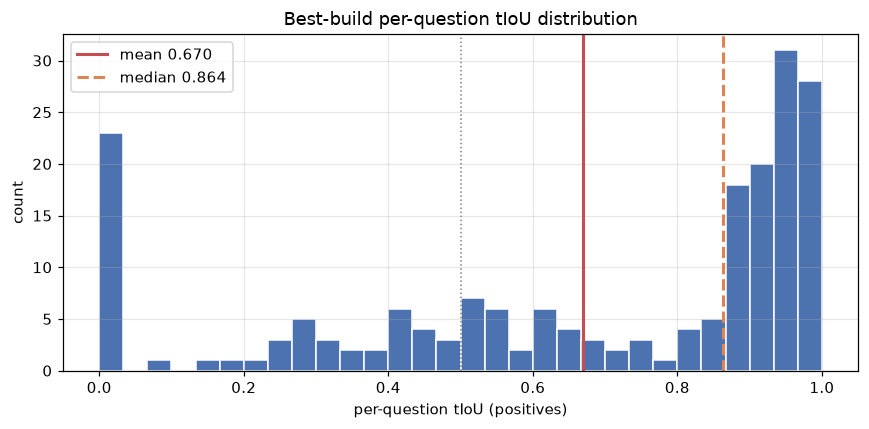

In [2]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pos["tiou"], bins=np.linspace(0, 1, 31), color="#4c72b0", edgecolor="white")
ax.axvline(mean_tiou, color="#c44e52", lw=2, label=f"mean {mean_tiou:.3f}")
ax.axvline(pos["tiou"].median(), color="#dd8452", lw=2, ls="--",
           label=f"median {pos['tiou'].median():.3f}")
ax.axvline(0.5, color="grey", lw=1, ls=":")
ax.set_xlabel("per-question tIoU (positives)")
ax.set_ylabel("count")
ax.set_title("Best-build per-question tIoU distribution")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "tiou_histogram.png", bbox_inches="tight")
plt.show()

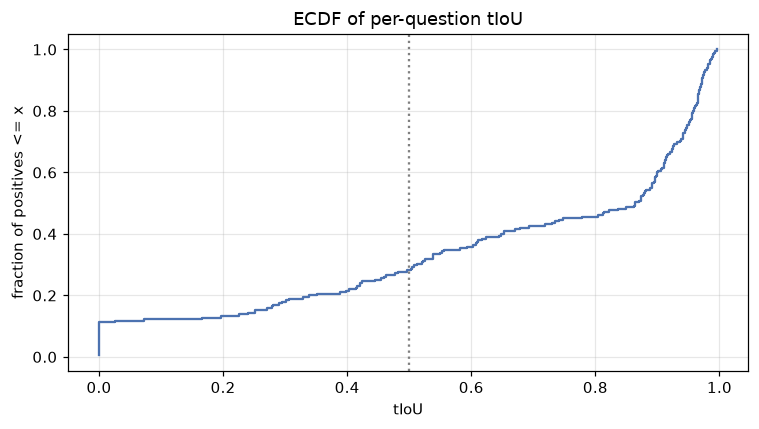

fraction with tIoU < 0.5: 0.282


In [3]:
x = np.sort(pos["tiou"].values)
y = np.arange(1, len(x) + 1) / len(x)
fig, ax = plt.subplots(figsize=(7, 4))
ax.step(x, y, where="post", color="#4c72b0")
ax.axvline(0.5, color="grey", ls=":")
ax.set_xlabel("tIoU")
ax.set_ylabel("fraction of positives <= x")
ax.set_title("ECDF of per-question tIoU")
fig.tight_layout()
fig.savefig(FIG / "tiou_ecdf.png", bbox_inches="tight")
plt.show()
print(f"fraction with tIoU < 0.5: {(pos['tiou'] < 0.5).mean():.3f}")

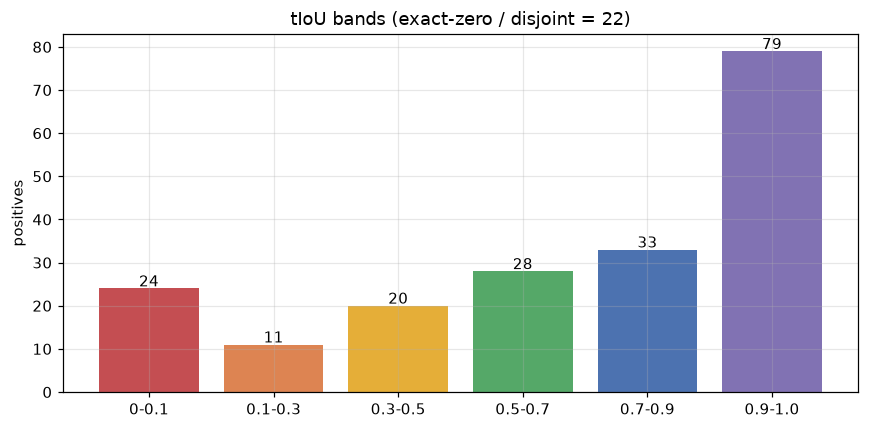

In [4]:
edges = [0.0, 0.1, 0.3, 0.5, 0.7, 0.9, 1.0001]
labels = ["0-0.1", "0.1-0.3", "0.3-0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
counts, _ = np.histogram(pos["tiou"], bins=edges)
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, counts, color=["#c44e52", "#dd8452", "#e5ae38", "#55a868", "#4c72b0", "#8172b3"])
for b, c in zip(bars, counts):
    ax.text(b.get_x() + b.get_width() / 2, c + 0.5, str(c), ha="center")
ax.set_ylabel("positives")
ax.set_title(f"tIoU bands (exact-zero / disjoint = {disjoint})")
fig.tight_layout()
fig.savefig(FIG / "tiou_bands.png", bbox_inches="tight")
plt.show()

## 2. Where the score lives

`score = 0.4 * accuracy + 0.6 * mean tIoU`. Accuracy is saturated (~0.997); essentially all
headroom is the tIoU half.


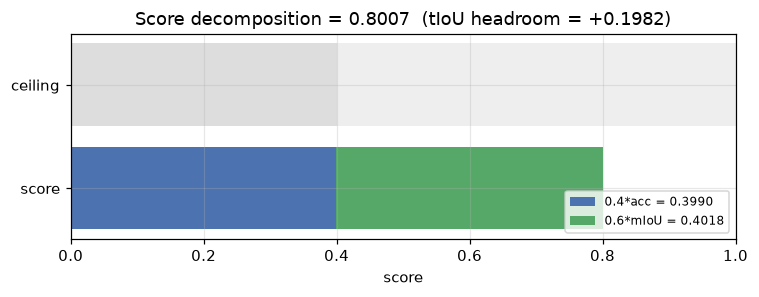

0.4*acc=0.3990  0.6*mIoU=0.4018
if mean tIoU were 1.0, score would rise by +0.1982


In [5]:
acc_part = 0.4 * accuracy
tiou_part = 0.6 * mean_tiou
fig, ax = plt.subplots(figsize=(7, 2.8))
ax.barh(["score"], [acc_part], color="#4c72b0", label=f"0.4*acc = {acc_part:.4f}")
ax.barh(["score"], [tiou_part], left=[acc_part], color="#55a868", label=f"0.6*mIoU = {tiou_part:.4f}")
ax.barh(["ceiling"], [0.4], color="#dddddd")
ax.barh(["ceiling"], [0.6], left=[0.4], color="#eeeeee")
ax.set_xlim(0, 1)
ax.set_xlabel("score")
ax.legend(loc="lower right", fontsize=8)
ax.set_title(f"Score decomposition = {score:.4f}  (tIoU headroom = +{0.6 * (1 - mean_tiou):.4f})")
fig.tight_layout()
fig.savefig(FIG / "score_decomposition.png", bbox_inches="tight")
plt.show()
print(f"0.4*acc={acc_part:.4f}  0.6*mIoU={tiou_part:.4f}")
print(f"if mean tIoU were 1.0, score would rise by +{0.6 * (1 - mean_tiou):.4f}")

## 3. Extent and occurrence diagnostics

Whether failures are boundary (extent) or occurrence (a different but valid mention) errors.


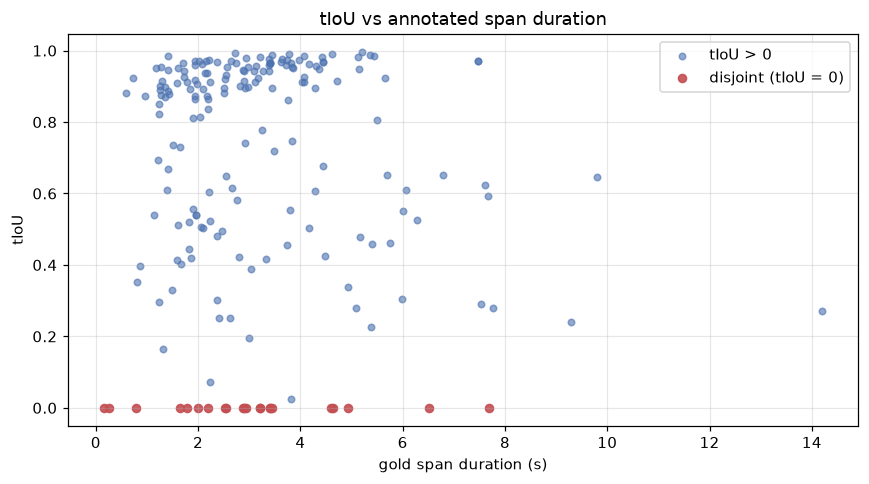

          count      mean
gold_dur                 
(0, 2]       57  0.666068
(2, 4]       88  0.693405
(4, 8]       47  0.647500
(8, 15]       3  0.385420


In [6]:
is_zero = pos["tiou"] == 0
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(pos.loc[~is_zero, "gold_dur"], pos.loc[~is_zero, "tiou"],
           s=18, alpha=0.6, color="#4c72b0", label="tIoU > 0")
ax.scatter(pos.loc[is_zero, "gold_dur"], pos.loc[is_zero, "tiou"],
           s=28, alpha=0.9, color="#c44e52", label="disjoint (tIoU = 0)")
ax.set_xlabel("gold span duration (s)")
ax.set_ylabel("tIoU")
ax.set_title("tIoU vs annotated span duration")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "tiou_vs_gold_duration.png", bbox_inches="tight")
plt.show()
buckets = pd.cut(pos["gold_dur"], [0, 2, 4, 8, 15])
print(pos.groupby(buckets, observed=True)["tiou"].agg(["count", "mean"]))

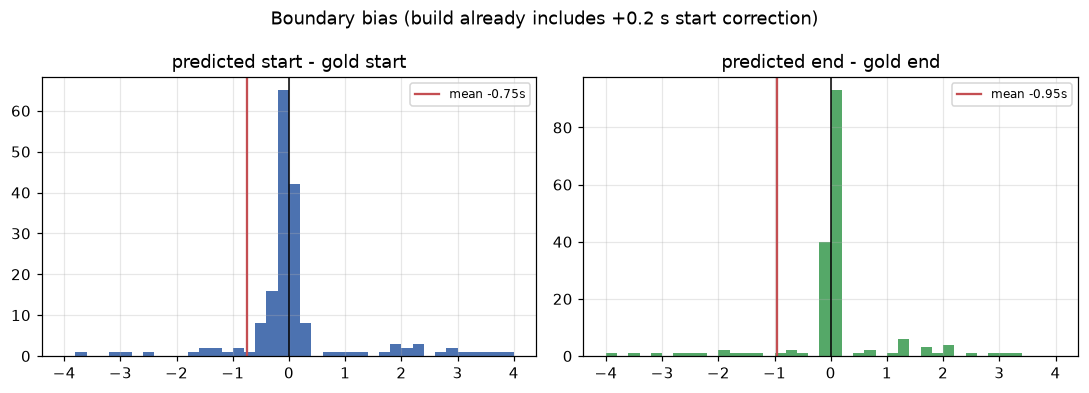

start bias mean=-0.746s  end bias mean=-0.949s


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(pos["d_start"].dropna(), bins=40, range=(-4, 4), color="#4c72b0")
axes[0].axvline(0, color="k", lw=1)
axes[0].axvline(pos["d_start"].mean(), color="#c44e52", lw=1.5,
                label=f"mean {pos['d_start'].mean():+.2f}s")
axes[0].set_title("predicted start - gold start")
axes[0].legend(fontsize=8)
axes[1].hist(pos["d_end"].dropna(), bins=40, range=(-4, 4), color="#55a868")
axes[1].axvline(0, color="k", lw=1)
axes[1].axvline(pos["d_end"].mean(), color="#c44e52", lw=1.5,
                label=f"mean {pos['d_end'].mean():+.2f}s")
axes[1].set_title("predicted end - gold end")
axes[1].legend(fontsize=8)
fig.suptitle("Boundary bias (build already includes +0.2 s start correction)")
fig.tight_layout()
fig.savefig(FIG / "boundary_bias.png", bbox_inches="tight")
plt.show()
print(f"start bias mean={pos['d_start'].mean():+.3f}s  end bias mean={pos['d_end'].mean():+.3f}s")

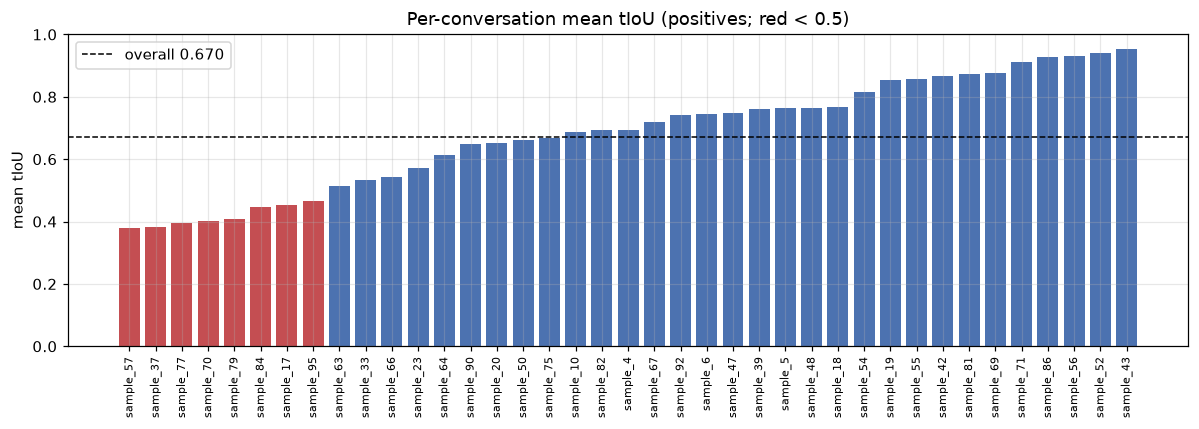

                   mean  count
transcript_id                 
sample_57      0.378729      7
sample_37      0.381074      6
sample_77      0.395428      7
sample_70      0.403051      6
sample_79      0.407645      5
sample_84      0.448230      7
sample_17      0.453426      3
sample_95      0.466387      3


In [8]:
conv = pos.groupby("transcript_id")["tiou"].agg(["mean", "count"]).sort_values("mean")
fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#c44e52" if m < 0.5 else "#4c72b0" for m in conv["mean"]]
ax.bar(conv.index.astype(str), conv["mean"], color=colors)
ax.axhline(mean_tiou, color="k", ls="--", lw=1, label=f"overall {mean_tiou:.3f}")
ax.set_xticks(range(len(conv)))
ax.set_xticklabels(conv.index.astype(str), rotation=90, fontsize=7)
ax.set_ylabel("mean tIoU")
ax.set_title("Per-conversation mean tIoU (positives; red < 0.5)")
ax.legend()
fig.tight_layout()
fig.savefig(FIG / "per_conversation_tiou.png", bbox_inches="tight")
plt.show()
print(conv.head(8))

## 5. Disjoint occurrences: genuine errors vs convention vs annotation bugs

For each of the 22 disjoint (tIoU = 0) positives we compare three annotators:
the **gold** (scored), the **model** prediction, and an **independent agent draft**
(`annotations/drafts/ALL.json`). A case is classified as:

- **degenerate gold** — annotated span < 1 s (greeting/fragment annotations);
- **subjective / convention** — the independent agent sides with the *model*
  (`IoU(agent, model) > IoU(agent, gold)`), i.e. a valid alternative occurrence;
- **genuine model error** — the agent sides with gold (or neither).

Then we ask what `mean tIoU` would be if only the genuine errors were counted.


In [9]:
import sys
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))
from answerers.align import align_quote_matches

DRAFTS = {
    r["question_id"]: r
    for r in json.loads((REPO / "annotations" / "drafts" / "ALL.json").read_text())
}
_words_cache = {}


def _load_words(tid, filename=None):
    key = (tid, filename)
    if key in _words_cache:
        return _words_cache[key]
    candidates = [REPO / filename] if filename else []
    candidates.extend(sorted((REPO / "transcripts").glob(f"conversation_{tid}.*.json")))
    for path in candidates:
        if path.exists():
            found = json.loads(path.read_text()).get("words")
            if found:
                _words_cache[key] = found
                return found
    _words_cache[key] = []
    return []


def _agent_span(tid, quote, filename=None):
    if not quote:
        return None
    matches = align_quote_matches(_load_words(tid, filename), quote)
    return [round(matches[0][0], 3), round(matches[0][1], 3)] if matches else None


def _iou(a, b):
    if not a or not b:
        return 0.0
    inter = max(0.0, min(a[1], b[1]) - max(a[0], b[0]))
    union = (a[1] - a[0]) + (b[1] - b[0]) - inter
    return inter / union if union > 0 else 0.0


_rows = []
for _, r in pos[pos["tiou"] == 0.0].iterrows():
    draft = DRAFTS.get(r["question_id"], {})
    agent = _agent_span(r["transcript_id"], draft.get("quote"), draft.get("transcript_file"))
    gold_duration = (r["gold"][1] - r["gold"][0]) if r["gold"] else 0.0
    iou_ag, iou_am = _iou(agent, r["gold"]), _iou(agent, r["span"])
    if gold_duration < 1.0:
        category = "degenerate gold"
    elif agent is not None and iou_am > iou_ag:
        category = "subjective / convention"
    else:
        category = "genuine model error"
    _rows.append({
        "question_id": r["question_id"], "gold": str(r["gold"]), "model": str(r["span"]),
        "agent": str(agent), "iou_agent_gold": round(iou_ag, 3),
        "iou_agent_model": round(iou_am, 3), "category": category,
    })

disjoint_rows = pd.DataFrame(_rows)
print(disjoint_rows.to_string(index=False))
print()
print(disjoint_rows["category"].value_counts().to_string())

_accuracy = float((df["prediction"] == df["label"]).mean())
_genuine = set(disjoint_rows.loc[disjoint_rows["category"] == "genuine model error", "question_id"])
_degenerate = set(disjoint_rows.loc[disjoint_rows["category"] == "degenerate gold", "question_id"])
_non_genuine = set(disjoint_rows.loc[disjoint_rows["category"] != "genuine model error", "question_id"])
_base_miou = float(pos["tiou"].mean())
_credited = pos["tiou"].copy()
_credited[pos["question_id"].isin(_non_genuine)] = 1.0
_credited_miou = float(_credited.mean())
_excl_degen_miou = float(pos.loc[~pos["question_id"].isin(_degenerate), "tiou"].mean())
_score = lambda m: 0.4 * _accuracy + 0.6 * m
print()
print(f"as-is mIoU                      {_base_miou:.4f}  (score {_score(_base_miou):.4f})")
print(f"exclude degenerate gold         {_excl_degen_miou:.4f}  (score {_score(_excl_degen_miou):.4f})")
print(f"only genuine errors counted     {_credited_miou:.4f}  (score {_score(_credited_miou):.4f})  "
      f"[+{_credited_miou - _base_miou:.4f} mIoU]")

      question_id                       gold            model            agent  iou_agent_gold  iou_agent_model                category
 sample_6_yes_q05              [72.96, 77.6]   [12.82, 14.98]   [42.58, 46.58]           0.000            0.000     genuine model error
sample_17_yes_q01              [48.18, 50.7]    [42.74, 45.5]    [47.92, 50.5]           0.835            0.000     genuine model error
sample_20_yes_q05           [182.44, 184.98]   [42.32, 43.78]   [41.98, 43.74]           0.000            0.789 subjective / convention
sample_23_yes_q02              [85.28, 88.5]   [19.96, 20.92]    [19.64, 20.8]           0.000            0.656 subjective / convention
sample_23_yes_q04               [90.2, 92.2]    [67.74, 70.0]   [67.42, 69.82]           0.000            0.806 subjective / convention
sample_33_yes_q03             [55.34, 58.28]   [25.86, 26.62]     [25.6, 26.5]           0.000            0.627 subjective / convention
sample_37_yes_q04             [17.58, 22.18]   [

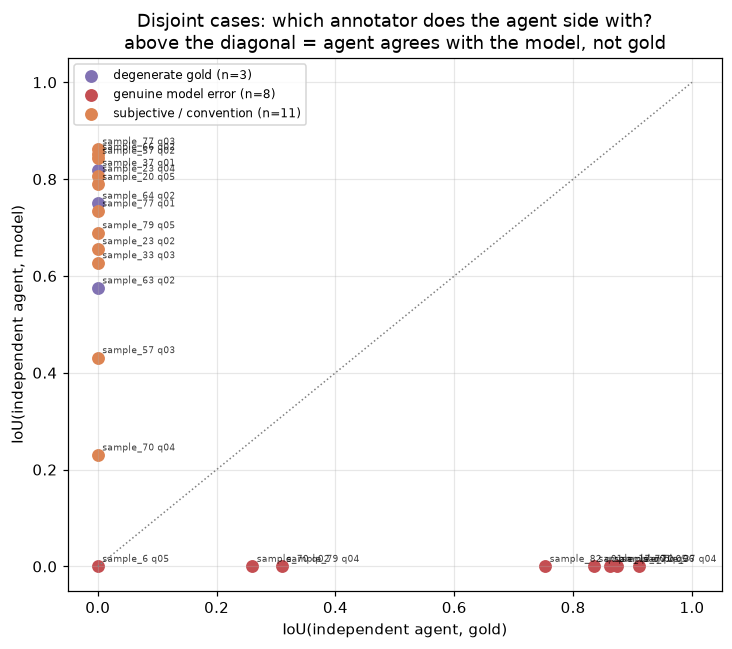

In [10]:
colors = {
    "genuine model error": "#c44e52",
    "subjective / convention": "#dd8452",
    "degenerate gold": "#8172b3",
}
fig, ax = plt.subplots(figsize=(6.8, 6))
ax.plot([0, 1], [0, 1], color="grey", ls=":", lw=1)
for category, group in disjoint_rows.groupby("category"):
    ax.scatter(group["iou_agent_gold"], group["iou_agent_model"], s=55,
               color=colors.get(category, "grey"), label=f"{category} (n={len(group)})")
for _, r in disjoint_rows.iterrows():
    ax.annotate(r["question_id"].replace("_yes_", " "), (r["iou_agent_gold"], r["iou_agent_model"]),
                fontsize=6, alpha=0.75, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("IoU(independent agent, gold)")
ax.set_ylabel("IoU(independent agent, model)")
ax.set_title("Disjoint cases: which annotator does the agent side with?\n"
             "above the diagonal = agent agrees with the model, not gold")
ax.legend(loc="upper left", fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "disjoint_agent_allegiance.png", bbox_inches="tight")
plt.show()

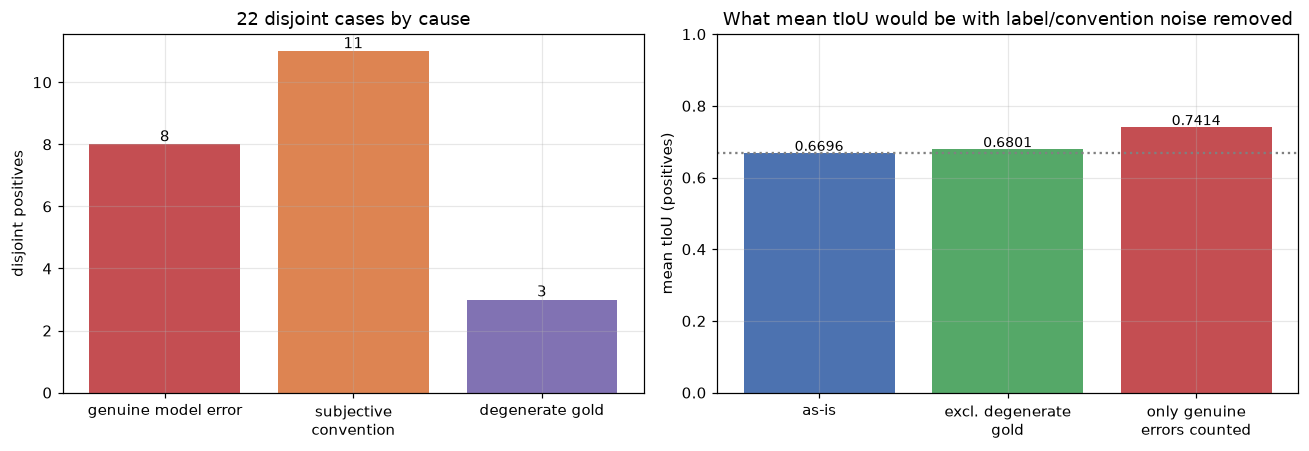

accuracy 0.9974
genuine-error cases account for 0.2586 of mean tIoU


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

counts = disjoint_rows["category"].value_counts()
order = ["genuine model error", "subjective / convention", "degenerate gold"]
axes[0].bar([o.replace(" / ", "\n") for o in order],
            [counts.get(o, 0) for o in order],
            color=[colors[o] for o in order])
for i, o in enumerate(order):
    axes[0].text(i, counts.get(o, 0) + 0.1, str(counts.get(o, 0)), ha="center")
axes[0].set_ylabel("disjoint positives")
axes[0].set_title("22 disjoint cases by cause")

labels = ["as-is", "excl. degenerate\ngold", "only genuine\nerrors counted"]
values = [_base_miou, _excl_degen_miou, _credited_miou]
axes[1].bar(labels, values, color=["#4c72b0", "#55a868", "#c44e52"])
for i, v in enumerate(values):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=9)
axes[1].axhline(_base_miou, color="grey", ls=":")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("mean tIoU (positives)")
axes[1].set_title("What mean tIoU would be with label/convention noise removed")
fig.tight_layout()
fig.savefig(FIG / "disjoint_miou_counterfactual.png", bbox_inches="tight")
plt.show()
print(f"accuracy {_accuracy:.4f}")
print(f"genuine-error cases account for {(1 - _credited_miou):.4f} of mean tIoU")

## 4. Takeaways and score-recovery arithmetic

- The loss is concentrated in a small number of disjoint/near-miss positives.
- The `+0.2 s` start correction is already applied in this build; the boundary-bias panel shows
  the residual.
- Because `mean tIoU` is averaged over **all** annotated positives, every unrecovered disjoint
  case drags the score down on both halves (0.4 accuracy and 0.6 tIoU).


near-miss band 0.4-0.5: 13 positives
baseline 0.8007 -> all near-misses perfect 0.8230 (+0.0222)


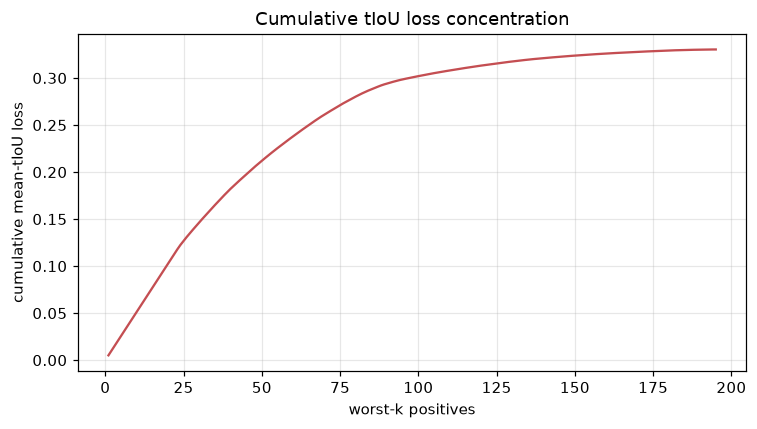

worst  5:   2.6% of the total mean-tIoU loss
worst 10:   5.1% of the total mean-tIoU loss
worst 22:  11.3% of the total mean-tIoU loss
worst 40:  18.2% of the total mean-tIoU loss


In [12]:
near = (pos["tiou"] >= 0.4) & (pos["tiou"] < 0.5)
recovered = pos["tiou"].copy()
recovered[near] = 1.0
new_mt = recovered.mean()
new_score = 0.4 * accuracy + 0.6 * new_mt
print(f"near-miss band 0.4-0.5: {int(near.sum())} positives")
print(f"baseline {score:.4f} -> all near-misses perfect {new_score:.4f} (+{new_score - score:.4f})")

loss = np.sort(1 - pos["tiou"].values)[::-1]
cum = np.cumsum(loss) / len(pos)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(np.arange(1, len(cum) + 1), cum, color="#c44e52")
ax.set_xlabel("worst-k positives")
ax.set_ylabel("cumulative mean-tIoU loss")
ax.set_title("Cumulative tIoU loss concentration")
fig.tight_layout()
fig.savefig(FIG / "cumulative_loss.png", bbox_inches="tight")
plt.show()
for k in (5, 10, 22, 40):
    print(f"worst {k:>2}: {cum[k - 1] * 100:5.1f}% of the total mean-tIoU loss")

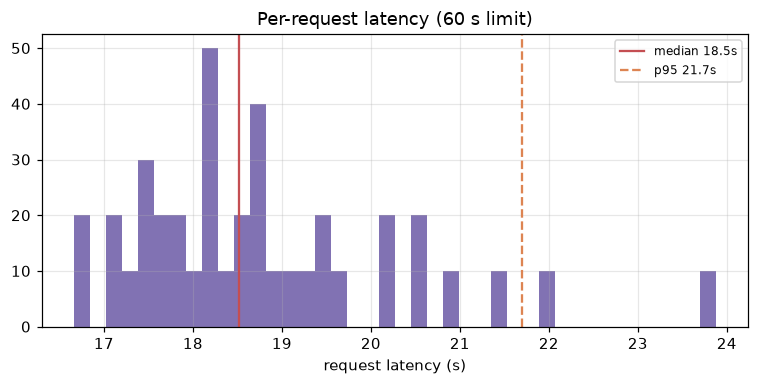

In [13]:
lat = df["request_latency_ms"] / 1000.0
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.hist(lat.dropna(), bins=40, color="#8172b3")
ax.axvline(lat.median(), color="#c44e52", lw=1.5, label=f"median {lat.median():.1f}s")
ax.axvline(lat.quantile(0.95), color="#dd8452", lw=1.5, ls="--",
           label=f"p95 {lat.quantile(0.95):.1f}s")
ax.set_xlabel("request latency (s)")
ax.set_title("Per-request latency (60 s limit)")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIG / "latency.png", bbox_inches="tight")
plt.show()

In [14]:
print("BEST-BUILD tIoU LOSS SUMMARY")
print("=" * 40)
print(f"accuracy           {accuracy:.4f}")
print(f"mean tIoU          {mean_tiou:.4f}")
print(f"score              {score:.4f}")
print(f"disjoint (tIoU=0)  {disjoint} / {len(pos)} positives")
print(f"tIoU < 0.5         {int((pos['tiou'] < 0.5).sum())} / {len(pos)}")
print(f"tIoU headroom      +{0.6 * (1 - mean_tiou):.4f} score if localization were perfect")
print(f"worst-22 loss      {np.sort(1 - pos['tiou'].values)[::-1][:22].sum() / len(pos) * 100:.1f}% of mean-tIoU loss")
print(f"latency p50/p95    {lat.median():.1f}s / {lat.quantile(0.95):.1f}s")
print()
print("disjoint breakdown (of 22)")
print(f"  genuine model errors        {len(_genuine)}")
print(f"  subjective / convention     {len(disjoint_rows) - len(_genuine) - len(_degenerate)}")
print(f"  degenerate gold             {len(_degenerate)}")
print(f"  only genuine errors counted mIoU {_credited_miou:.4f} (score {_score(_credited_miou):.4f})")

BEST-BUILD tIoU LOSS SUMMARY
accuracy           0.9974
mean tIoU          0.6696
score              0.8007
disjoint (tIoU=0)  22 / 195 positives
tIoU < 0.5         55 / 195
tIoU headroom      +0.1982 score if localization were perfect
worst-22 loss      11.3% of mean-tIoU loss
latency p50/p95    18.5s / 21.7s

disjoint breakdown (of 22)
  genuine model errors        8
  subjective / convention     11
  degenerate gold             3
  only genuine errors counted mIoU 0.7414 (score 0.8438)
